In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ============================================================
# CELL 1 — Project Setup & Library Imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests
import re
import os
from collections import Counter

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ TensorFlow version:", tf.__version__)
print("✅ NumPy version:", np.__version__)
print("✅ All libraries imported successfully!")
print("\n📌 Project: Character-Level Language Model using LSTM")
print("📌 Dataset : The Adventures of Sherlock Holmes — Arthur Conan Doyle")
print("📌 Goal    : Train an LSTM to generate Sherlock Holmes-style text from scratch")

2026-04-11 10:05:33.623063: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775901934.017507      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775901934.129756      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775901935.107143      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775901935.107186      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775901935.107189      55 computation_placer.cc:177] computation placer alr

✅ TensorFlow version: 2.19.0
✅ NumPy version: 2.0.2
✅ All libraries imported successfully!

📌 Project: Character-Level Language Model using LSTM
📌 Dataset : The Adventures of Sherlock Holmes — Arthur Conan Doyle
📌 Goal    : Train an LSTM to generate Sherlock Holmes-style text from scratch


##  Section 1: Data Loading & Raw Text Exploration

We download *The Adventures of Sherlock Holmes* directly from **Project Gutenberg**.
This is a character-level language model — so our "vocabulary" is individual characters,
not words. Let's first understand what our raw text looks like.

In [2]:
# ============================================================
# CELL 2 — Download Dataset + Raw Text EDA
# ============================================================

# Download from Project Gutenberg (free, legal, clean)
url = "https://www.gutenberg.org/files/1661/1661-0.txt"
response = requests.get(url)
raw_text = response.text
print(f"✅ Downloaded! Total characters (raw): {len(raw_text):,}")

# ── Strip Gutenberg header/footer boilerplate ──────────────────
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_marker   = "*** END OF THE PROJECT GUTENBERG EBOOK"
start_idx = raw_text.find(start_marker)
end_idx   = raw_text.find(end_marker)
text = raw_text[start_idx:end_idx]

# Basic cleaning — keep letters, punctuation, newlines
text = re.sub(r'\r\n', '\n', text)          # normalize line endings
text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII
text = re.sub(r' {2,}', ' ', text)          # collapse multiple spaces
text = text.strip()

print(f"✅ After cleaning — Total characters : {len(text):,}")
print(f"✅ Total lines                        : {text.count(chr(10)):,}")
print(f"✅ Approx. word count                 : {len(text.split()):,}")

# ── Vocabulary ─────────────────────────────────────────────────
chars     = sorted(set(text))
vocab_size = len(chars)
print(f"\n📌 Vocabulary size (unique chars): {vocab_size}")
print(f"📌 Characters in vocab:\n{''.join(chars)}")

# ── Preview ────────────────────────────────────────────────────
print("\n" + "="*60)
print("📖 TEXT PREVIEW (chars 500–1500):")
print("="*60)
print(text[500:1500])

✅ Downloaded! Total characters (raw): 593,731
✅ After cleaning — Total characters : 559,958
✅ Total lines                        : 11,927
✅ Approx. word count                 : 105,240

📌 Vocabulary size (unique chars): 76
📌 Characters in vocab:

 !&()*,-.0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ_abcdefghijklmnopqrstuvwxyz

📖 TEXT PREVIEW (chars 500–1500):
enture of the Beryl Coronet
 XII. The Adventure of the Copper Beeches




I. A SCANDAL IN BOHEMIA


I.

To Sherlock Holmes she is always _the_ woman. I have seldom heard him
mention her under any other name. In his eyes she eclipses and
predominates the whole of her sex. It was not that he felt any emotion
akin to love for Irene Adler. All emotions, and that one particularly,
were abhorrent to his cold, precise but admirably balanced mind. He
was, I take it, the most perfect reasoning and observing machine that
the world has seen, but as a lover he would have placed himself in a
false position. He never spoke of the softer passions, sa

##  Section 2: Exploratory Data Analysis (EDA)

Before building any model, we analyze the text deeply:
- **Character frequency distribution** — which chars dominate?
- **Bigram heatmap** — which char follows which? (this is what LSTM learns!)
- **Word frequency** — most common words in the corpus
- **Text statistics summary**

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_55/462198954.py:96: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/462198954.py:97: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_sherlock.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_55/462198954.py:97: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_sherlock.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figu

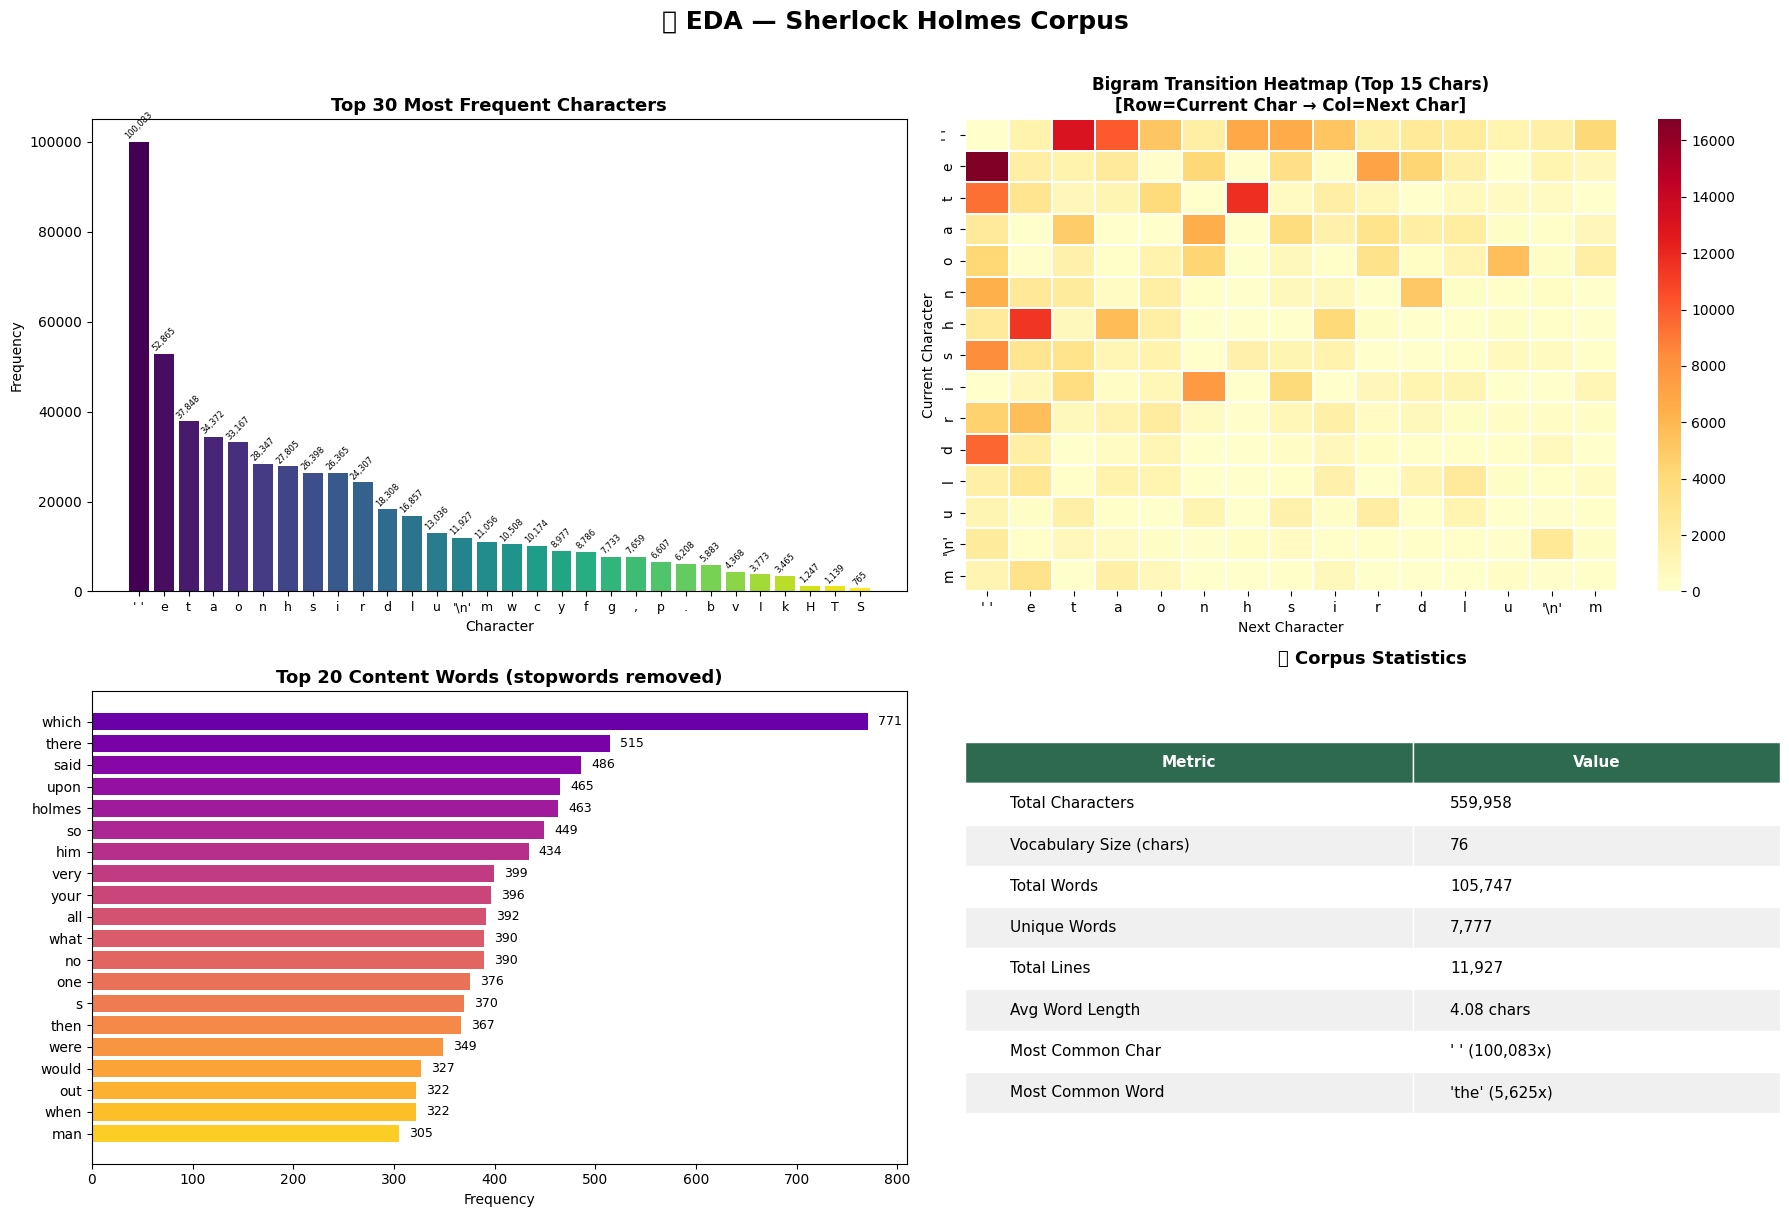

✅ EDA complete! 4 plots saved.


In [3]:
# ============================================================
# CELL 3 — Full EDA Visuals
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("📊 EDA — Sherlock Holmes Corpus", fontsize=18, fontweight='bold', y=1.01)

# ── 1. Character Frequency Bar Chart ──────────────────────────
char_counts = Counter(text)
# Top 30 most frequent chars
top_chars   = char_counts.most_common(30)
labels, values = zip(*top_chars)
labels_display = [repr(c) if c in (' ', '\n', '\t') else c for c in labels]

ax1 = axes[0, 0]
bars = ax1.bar(range(len(labels)), values, color=plt.cm.viridis(np.linspace(0, 1, 30)))
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels_display, fontsize=9)
ax1.set_title("Top 30 Most Frequent Characters", fontsize=13, fontweight='bold')
ax1.set_xlabel("Character")
ax1.set_ylabel("Frequency")
for i, (bar, val) in enumerate(zip(bars, values)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', va='bottom', fontsize=6, rotation=45)

# ── 2. Bigram Heatmap (top 15 chars only for readability) ─────
top15_chars = [c for c, _ in char_counts.most_common(15)]
bigram_matrix = np.zeros((15, 15), dtype=int)
for i in range(len(text) - 1):
    c1, c2 = text[i], text[i+1]
    if c1 in top15_chars and c2 in top15_chars:
        r, col = top15_chars.index(c1), top15_chars.index(c2)
        bigram_matrix[r][col] += 1

ax2 = axes[0, 1]
tick_labels = [repr(c) if c in (' ', '\n') else c for c in top15_chars]
sns.heatmap(bigram_matrix, xticklabels=tick_labels, yticklabels=tick_labels,
            cmap='YlOrRd', ax=ax2, fmt='d', annot=False, linewidths=0.3)
ax2.set_title("Bigram Transition Heatmap (Top 15 Chars)\n[Row=Current Char → Col=Next Char]",
              fontsize=12, fontweight='bold')
ax2.set_xlabel("Next Character")
ax2.set_ylabel("Current Character")

# ── 3. Top 20 Words Bar Chart ──────────────────────────────────
from collections import Counter as C
import re as re2
words      = re2.findall(r'\b[a-zA-Z]+\b', text.lower())
word_freq  = C(words)
# Remove stopwords for more interesting view
stopwords  = {'the','a','and','of','to','in','i','that','it','was','he','she',
              'his','her','had','have','been','for','with','at','on','as','but',
              'not','my','you','is','by','we','this','an','are','from','be','me'}
filtered   = {w: c for w, c in word_freq.items() if w not in stopwords}
top_words  = sorted(filtered.items(), key=lambda x: -x[1])[:20]
wlabels, wcounts = zip(*top_words)

ax3 = axes[1, 0]
ax3.barh(range(len(wlabels)), wcounts,
         color=plt.cm.plasma(np.linspace(0.2, 0.9, 20)))
ax3.set_yticks(range(len(wlabels)))
ax3.set_yticklabels(wlabels, fontsize=10)
ax3.invert_yaxis()
ax3.set_title("Top 20 Content Words (stopwords removed)", fontsize=13, fontweight='bold')
ax3.set_xlabel("Frequency")
for i, v in enumerate(wcounts):
    ax3.text(v + 10, i, str(v), va='center', fontsize=9)

# ── 4. Text Statistics Summary Table ──────────────────────────
ax4 = axes[1, 1]
ax4.axis('off')
stats = [
    ["Total Characters",        f"{len(text):,}"],
    ["Vocabulary Size (chars)", f"{vocab_size}"],
    ["Total Words",             f"{len(words):,}"],
    ["Unique Words",            f"{len(word_freq):,}"],
    ["Total Lines",             f"{text.count(chr(10)):,}"],
    ["Avg Word Length",         f"{np.mean([len(w) for w in words]):.2f} chars"],
    ["Most Common Char",        f"'{char_counts.most_common(1)[0][0]}' ({char_counts.most_common(1)[0][1]:,}x)"],
    ["Most Common Word",        f"'{word_freq.most_common(1)[0][0]}' ({word_freq.most_common(1)[0][1]:,}x)"],
]
table = ax4.table(cellText=stats, colLabels=["Metric", "Value"],
                  cellLoc='left', loc='center',
                  colWidths=[0.55, 0.45])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2d6a4f')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f0f0')
    cell.set_edgecolor('white')
ax4.set_title("📋 Corpus Statistics", fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('eda_sherlock.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA complete! 4 plots saved.")

##  Section 3: Preprocessing — Preparing Data for LSTM

Character-level LM preprocessing has 3 key steps:
1. **char↔int mapping** — convert every character to a unique integer
2. **Sliding window** — create (input_sequence → target_char) pairs
3. **Train/Val split** — 90/10 split before feeding to model

> **Why sequence length = 100?**  
> LSTM needs to see enough context to learn grammar & style.  
> 100 chars ≈ 1-2 sentences — enough for Sherlock's writing patterns.

📌 char→int mapping (first 15 chars):
   ''\n'' → 0
   '' '' → 1
   '!' → 2
   '&' → 3
   '(' → 4
   ')' → 5
   '*' → 6
   ',' → 7
   '-' → 8
   '.' → 9
   '0' → 10
   '1' → 11
   '2' → 12
   '3' → 13
   '4' → 14

✅ Encoded text shape: (559958,)
   First 20 encoded values: [ 6  6  6  1 41 42 23 40 42  1 37 28  1 42 30 27  1 38 40 37]
   Decoded back: *** START OF THE PRO

✅ Sliding window complete:
   SEQ_LEN : 100 chars
   STEP    : 3
   X shape : (186620, 100)  (samples × seq_len)
   y shape : (186620,)  (samples,)

   Example sequence (first):
   INPUT  → '*** START OF THE PROJECT GUTENBERG EBOOK THE ADVENTURES OF SHERLOCK
HOLMES ***




The Adventures of'
   TARGET → ' '

✅ Train/Val Split (90/10):
   X_train : (167958, 100)  |  y_train : (167958,)
   X_val   : (18662, 100)   |  y_val   : (18662,)


/tmp/ipykernel_55/984701904.py:75: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/984701904.py:76: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.savefig('sliding_window.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


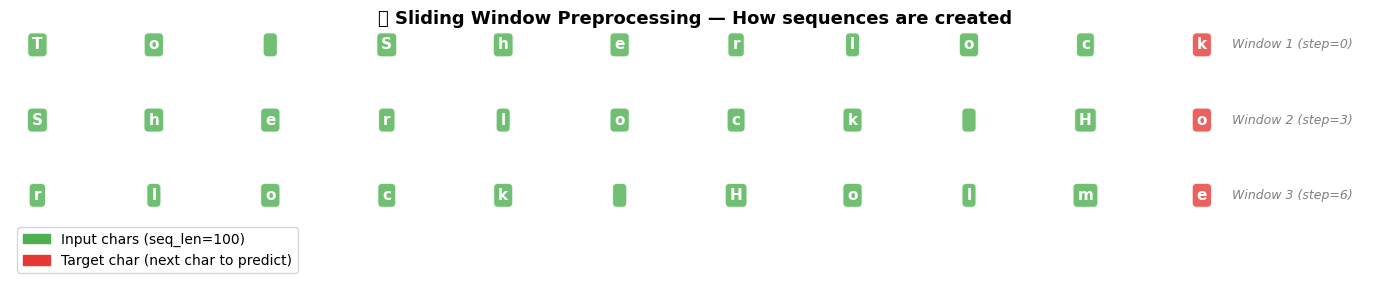


✅ Preprocessing complete! Ready for model building.


In [4]:
# ============================================================
# CELL 4 — Preprocessing: Mappings + Sliding Window + Split
# ============================================================

# ── 1. Character ↔ Integer Mappings ───────────────────────────
char2idx = {ch: idx for idx, ch in enumerate(chars)}
idx2char  = {idx: ch  for idx, ch in enumerate(chars)}

print("📌 char→int mapping (first 15 chars):")
for ch, idx in list(char2idx.items())[:15]:
    display_ch = repr(ch) if ch in (' ', '\n') else ch
    print(f"   '{display_ch}' → {idx}")

# ── 2. Encode entire text ──────────────────────────────────────
encoded = np.array([char2idx[ch] for ch in text], dtype=np.int32)
print(f"\n✅ Encoded text shape: {encoded.shape}")
print(f"   First 20 encoded values: {encoded[:20]}")
print(f"   Decoded back: {''.join([idx2char[i] for i in encoded[:20]])}")

# ── 3. Sliding Window Sequence Creation ───────────────────────
SEQ_LEN = 100   # input sequence length
STEP    = 3     # step size (overlapping windows for more data)

X_seqs, y_seqs = [], []
for i in range(0, len(encoded) - SEQ_LEN, STEP):
    X_seqs.append(encoded[i : i + SEQ_LEN])
    y_seqs.append(encoded[i + SEQ_LEN])        # next char = target

X = np.array(X_seqs, dtype=np.int32)
y = np.array(y_seqs, dtype=np.int32)

print(f"\n✅ Sliding window complete:")
print(f"   SEQ_LEN : {SEQ_LEN} chars")
print(f"   STEP    : {STEP}")
print(f"   X shape : {X.shape}  (samples × seq_len)")
print(f"   y shape : {y.shape}  (samples,)")
print(f"\n   Example sequence (first):")
print(f"   INPUT  → '{''.join([idx2char[i] for i in X[0]])}'")
print(f"   TARGET → '{idx2char[y[0]]}'")

# ── 4. Train / Validation Split ───────────────────────────────
split      = int(0.9 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print(f"\n✅ Train/Val Split (90/10):")
print(f"   X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"   X_val   : {X_val.shape}   |  y_val   : {y_val.shape}")

# ── 5. Visualise the sliding window concept ────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
ax.set_title("🔄 Sliding Window Preprocessing — How sequences are created",
             fontsize=13, fontweight='bold', pad=15)

sample_text = "To Sherlock Holmes she is always the woman"
colors_seq  = ['#4CAF50'] * 10 + ['#E53935']  # green=input, red=target

for step_i, start in enumerate([0, 3, 6]):
    y_pos = 1 - step_i * 0.32
    for j, ch in enumerate(sample_text[start:start+11]):
        color = '#4CAF50' if j < 10 else '#E53935'
        ax.text(j * 0.085 + 0.02, y_pos, ch,
                fontsize=11, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                          alpha=0.8, edgecolor='white'),
                color='white', fontweight='bold')
    label = f"Window {step_i+1} (step={start})"
    ax.text(0.98, y_pos, label, fontsize=9, ha='right', va='center',
            style='italic', color='gray')

legend_els = [mpatches.Patch(color='#4CAF50', label='Input chars (seq_len=100)'),
              mpatches.Patch(color='#E53935', label='Target char (next char to predict)')]
ax.legend(handles=legend_els, loc='lower left', fontsize=10)
plt.tight_layout()
plt.savefig('sliding_window.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Preprocessing complete! Ready for model building.")


##  Section 4: Model Architecture — Stacked LSTM

### Why this architecture?
| Component | Reason |
|---|---|
| `Embedding layer` | Learns dense char representations (better than one-hot) |
| `LSTM (256 units)` | Captures short-term patterns — spelling, punctuation |
| `Dropout(0.3)` | Prevents memorizing text, forces generalization |
| `LSTM (128 units)` | Captures longer-term patterns — sentence structure, style |
| `Dropout(0.3)` | Second regularization layer |
| `Dense(vocab_size, softmax)` | Outputs probability over all 76 chars |

> The model reads 100 chars → predicts the 1 most likely next char.  
> Trained on 167,958 sequences from Sherlock Holmes.

In [5]:
# ============================================================
# CELL 5 (FIXED) — Build + Force-Build Model
# ============================================================

EMBED_DIM   = 64
LSTM1_UNITS = 256
LSTM2_UNITS = 128

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, name='Embedding'),
    LSTM(LSTM1_UNITS, return_sequences=True, name='LSTM_1'),
    Dropout(0.3, name='Dropout_1'),
    LSTM(LSTM2_UNITS, return_sequences=False, name='LSTM_2'),
    Dropout(0.3, name='Dropout_2'),
    Dense(vocab_size, activation='softmax', name='Output')
], name='Sherlock_CharLM')

# ✅ Force build by passing a dummy input
dummy = np.zeros((1, SEQ_LEN), dtype=np.int32)
model(dummy)

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()

total_params = model.count_params()
print(f"\n✅ Total trainable parameters: {total_params:,}")

I0000 00:00:1775901994.784307      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775901994.790501      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1775901997.720692     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


Model: "Sherlock_CharLM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding (Embedding)           │ (1, 100, 64)           │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_1 (LSTM)                   │ (1, 100, 256)          │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (1, 100, 256)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (1, 128)               │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (1, 76)                │         9,804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 540,492 (2.06 MB)

 Trainable params: 540,492 (2.06 MB)

 Non-trainable params: 0 (0.00 B)


✅ Total trainable parameters: 540,492


##  Section 5: Architecture Diagram + Training

Now we visualize the model architecture, then train with:
- **EarlyStopping** — stops if val_loss doesn't improve for 3 epochs  
- **ReduceLROnPlateau** — halves learning rate when stuck  
- **ModelCheckpoint** — saves best model weights automatically

/tmp/ipykernel_55/2305274896.py:67: UserWarning: Glyph 128229 (\N{INBOX TRAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/2305274896.py:67: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/2305274896.py:67: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/2305274896.py:67: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/2305274896.py:67: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/2305274896.py:67: UserWarning: Glyph 128228 (\N{OUTBOX TRAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/2305274896.py:68: UserWarning: Glyph 128229 (\N{INBOX TRAY}) missing from font(s) DejaVu Sans.
  plt.savefig('lstm_architecture.png', dpi=150,
/tmp

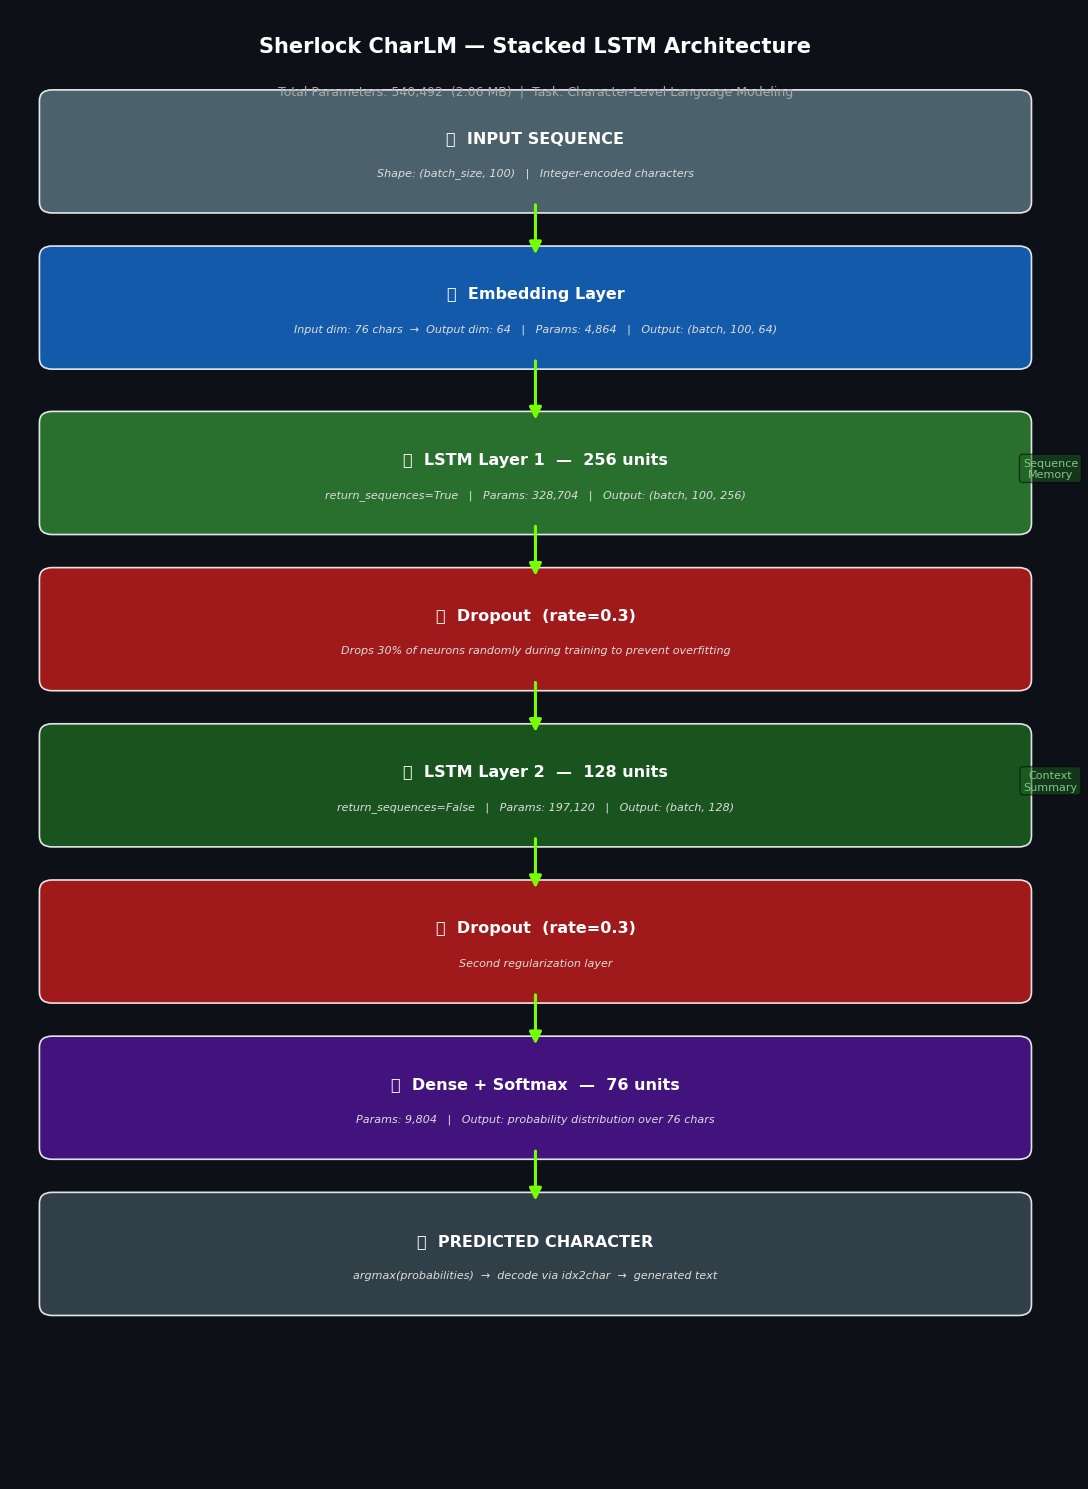

✅ Architecture diagram saved!


In [6]:
# ============================================================
# CELL 6 — Architecture Diagram (Clean Version)
# ============================================================

fig, ax = plt.subplots(figsize=(11, 15))
ax.set_xlim(0, 10)
ax.set_ylim(0, 16)
ax.axis('off')
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')

layers_info = [
    (14.5, '#546E7A', '📥  INPUT SEQUENCE',
     f'Shape: (batch_size, {SEQ_LEN})   |   Integer-encoded characters'),
    (12.8, '#1565C0', '🔵  Embedding Layer',
     f'Input dim: {vocab_size} chars  →  Output dim: {EMBED_DIM}   |   Params: 4,864   |   Output: (batch, {SEQ_LEN}, {EMBED_DIM})'),
    (11.0, '#2E7D32', '🟢  LSTM Layer 1  —  256 units',
     f'return_sequences=True   |   Params: 328,704   |   Output: (batch, {SEQ_LEN}, 256)'),
    (9.3,  '#B71C1C', '🔴  Dropout  (rate=0.3)',
     'Drops 30% of neurons randomly during training to prevent overfitting'),
    (7.6,  '#1B5E20', '🟢  LSTM Layer 2  —  128 units',
     f'return_sequences=False   |   Params: 197,120   |   Output: (batch, 128)'),
    (5.9,  '#B71C1C', '🔴  Dropout  (rate=0.3)',
     'Second regularization layer'),
    (4.2,  '#4A148C', '🟣  Dense + Softmax  —  76 units',
     f'Params: 9,804   |   Output: probability distribution over {vocab_size} chars'),
    (2.5,  '#37474F', '📤  PREDICTED CHARACTER',
     'argmax(probabilities)  →  decode via idx2char  →  generated text'),
]

for i, (y, color, label, sub) in enumerate(layers_info):
    rect = mpatches.FancyBboxPatch(
        (0.4, y - 0.6), 9.2, 1.1,
        boxstyle="round,pad=0.12",
        facecolor=color, alpha=0.88,
        edgecolor='#ffffff', linewidth=1.2)
    ax.add_patch(rect)
    ax.text(5, y + 0.1, label, ha='center', va='center',
            fontsize=11.5, fontweight='bold', color='white')
    ax.text(5, y - 0.28, sub, ha='center', va='center',
            fontsize=8, color='#dddddd', style='italic')
    if i < len(layers_info) - 1:
        next_y = layers_info[i+1][0]
        ax.annotate('', xy=(5, next_y + 0.5),
                    xytext=(5, y - 0.6),
                    arrowprops=dict(arrowstyle='-|>',
                                   color='#76FF03', lw=2.2,
                                   mutation_scale=18))

# Title + param summary
ax.text(5, 15.6,
        'Sherlock CharLM — Stacked LSTM Architecture',
        ha='center', va='center', fontsize=15,
        fontweight='bold', color='white')
ax.text(5, 15.1,
        'Total Parameters: 540,492  (2.06 MB)  |  Task: Character-Level Language Modeling',
        ha='center', va='center', fontsize=9, color='#aaaaaa')

# Side annotations
ax.text(9.9, 11.0, 'Sequence\nMemory', ha='center', va='center',
        fontsize=8, color='#81C784',
        bbox=dict(boxstyle='round', facecolor='#1B5E20', alpha=0.5))
ax.text(9.9, 7.6, 'Context\nSummary', ha='center', va='center',
        fontsize=8, color='#81C784',
        bbox=dict(boxstyle='round', facecolor='#1B5E20', alpha=0.5))

plt.tight_layout()
plt.savefig('lstm_architecture.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Architecture diagram saved!")

In [8]:
# ============================================================
# CELL 7 — Training with Callbacks
# ============================================================

from tensorflow.keras.callbacks import (EarlyStopping,
                                         ReduceLROnPlateau,
                                         ModelCheckpoint)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-5, verbose=1),
    ModelCheckpoint('best_sherlock_lstm.keras',
                    monitor='val_loss', save_best_only=True, verbose=1),
]

print("🚀 Starting training...")
print(f"   Training samples : {X_train.shape[0]:,}")
print(f"   Validation samples: {X_val.shape[0]:,}")
print(f"   Batch size        : 256")
print(f"   Max epochs        : 30  (EarlyStopping will likely stop earlier)\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=256,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")
print(f"   Best val_loss    : {min(history.history['val_loss']):.4f}")
print(f"   Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"   Epochs trained   : {len(history.history['loss'])}")

🚀 Starting training...
   Training samples : 167,958
   Validation samples: 18,662
   Batch size        : 256
   Max epochs        : 30  (EarlyStopping will likely stop earlier)

Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2100 - loss: 2.9876
Epoch 1: val_loss improved from inf to 2.31073, saving model to best_sherlock_lstm.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.2100 - loss: 2.9872 - val_accuracy: 0.3455 - val_loss: 2.3107 - learning_rate: 0.0010
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3464 - loss: 2.2933
Epoch 2: val_loss improved from 2.31073 to 2.11282, saving model to best_sherlock_lstm.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.3464 - loss: 2.2932 - val_accuracy: 0.3855 - val_loss: 2.1128 - learning_rate: 0.0010
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3853 - loss: 2.1335
Epoch 3: val_loss improved from 2.11282 to 2.00085, saving model to best_sherlock_lstm.keras

In [7]:
# GPU Check Cell — run this after switching to GPU
import tensorflow as tf
import numpy as np

gpus = tf.config.list_physical_devices('GPU')
print("✅ GPUs detected:", gpus)
print("✅ TF version:", tf.__version__)

if gpus:
    print(f"\n🚀 GPU is ACTIVE — Training will be blazing fast!")
else:
    print("\n⚠️ No GPU found — check Kaggle accelerator settings")

✅ GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ TF version: 2.19.0

🚀 GPU is ACTIVE — Training will be blazing fast!


##  Section 6: Training Curves + Evaluation + Text Generation

Training complete! Now we:
1. Plot loss & accuracy curves
2. Calculate Perplexity (standard LM metric)
3. Generate Sherlock-style text using **temperature sampling**

/tmp/ipykernel_55/1188587528.py:57: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1188587528.py:57: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1188587528.py:57: UserWarning: Glyph 128292 (\N{INPUT SYMBOL FOR LATIN LETTERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1188587528.py:58: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150,
/tmp/ipykernel_55/1188587528.py:58: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150,
/tmp/ipykernel_55/1188587528.py:58: UserWarning: Glyph 128292 (\N{INPUT SYMBOL FOR LATIN LETTERS}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150,
/usr/local/lib/python

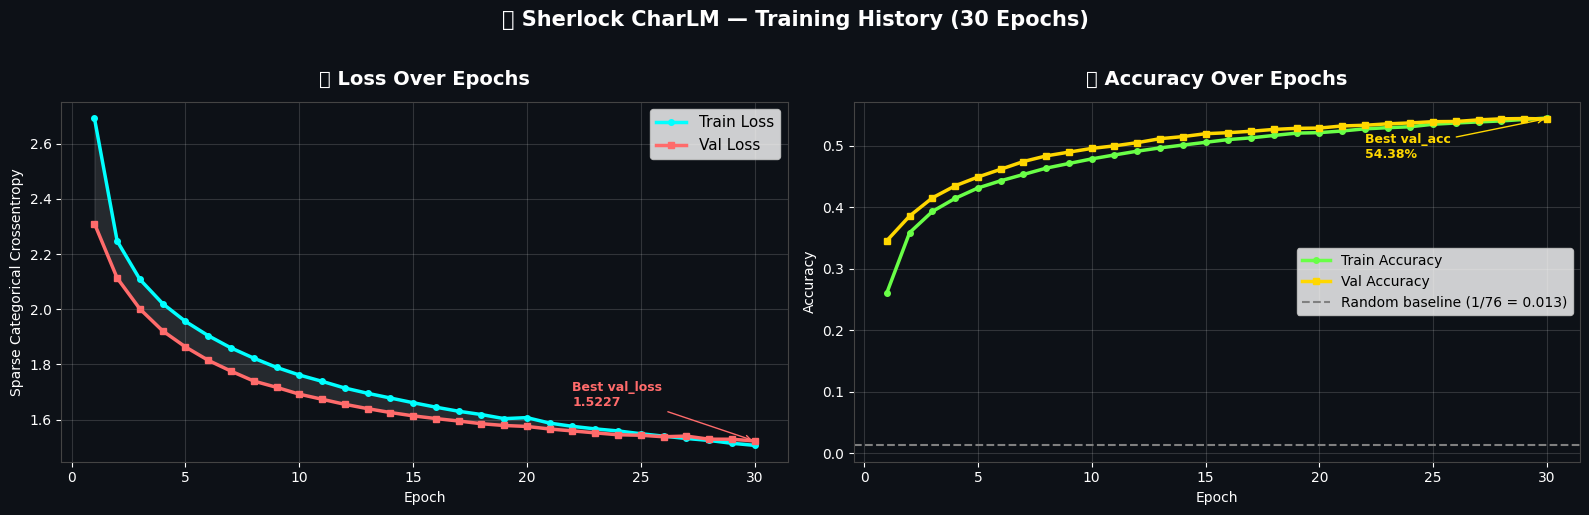

✅ Training curves saved!


In [9]:
# ============================================================
# CELL 8 — Loss & Accuracy Curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

epochs_range = range(1, len(history.history['loss']) + 1)

# ── Loss Curve ─────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#0d1117')
ax1.plot(epochs_range, history.history['loss'],
         'cyan', linewidth=2.5, marker='o', markersize=4, label='Train Loss')
ax1.plot(epochs_range, history.history['val_loss'],
         '#FF6B6B', linewidth=2.5, marker='s', markersize=4, label='Val Loss')
ax1.fill_between(epochs_range, history.history['loss'],
                 history.history['val_loss'], alpha=0.1, color='white')
ax1.set_title('📉 Loss Over Epochs', fontsize=14,
              fontweight='bold', color='white', pad=12)
ax1.set_xlabel('Epoch', color='white')
ax1.set_ylabel('Sparse Categorical Crossentropy', color='white')
ax1.tick_params(colors='white')
ax1.legend(fontsize=11)
ax1.spines[['bottom','left','top','right']].set_color('#444')
ax1.annotate(f'Best val_loss\n1.5227',
             xy=(30, 1.5227), xytext=(22, 1.65),
             arrowprops=dict(arrowstyle='->', color='#FF6B6B'),
             color='#FF6B6B', fontsize=9, fontweight='bold')

# ── Accuracy Curve ─────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#0d1117')
ax2.plot(epochs_range, history.history['accuracy'],
         '#69FF47', linewidth=2.5, marker='o', markersize=4, label='Train Accuracy')
ax2.plot(epochs_range, history.history['val_accuracy'],
         '#FFD700', linewidth=2.5, marker='s', markersize=4, label='Val Accuracy')
ax2.axhline(y=1/vocab_size, color='gray', linestyle='--',
            linewidth=1.5, label=f'Random baseline (1/{vocab_size} = {1/vocab_size:.3f})')
ax2.set_title('📈 Accuracy Over Epochs', fontsize=14,
              fontweight='bold', color='white', pad=12)
ax2.set_xlabel('Epoch', color='white')
ax2.set_ylabel('Accuracy', color='white')
ax2.tick_params(colors='white')
ax2.legend(fontsize=10)
ax2.spines[['bottom','left','top','right']].set_color('#444')
ax2.annotate(f'Best val_acc\n54.38%',
             xy=(30, 0.5438), xytext=(22, 0.48),
             arrowprops=dict(arrowstyle='->', color='#FFD700'),
             color='#FFD700', fontsize=9, fontweight='bold')

for ax in axes:
    ax.grid(True, alpha=0.15, color='white')

plt.suptitle('🔤 Sherlock CharLM — Training History (30 Epochs)',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Training curves saved!")

In [10]:
# ============================================================
# CELL 9 — Perplexity + Text Generation with Temperature
# ============================================================

import math

# ── Perplexity ─────────────────────────────────────────────────
best_val_loss = min(history.history['val_loss'])
perplexity    = math.exp(best_val_loss)
print("=" * 55)
print("📊 EVALUATION METRICS")
print("=" * 55)
print(f"  Best Val Loss  : {best_val_loss:.4f}")
print(f"  Perplexity     : {perplexity:.2f}")
print(f"  Val Accuracy   : {max(history.history['val_accuracy'])*100:.2f}%")
print(f"  Random Baseline: {1/vocab_size*100:.2f}%")
print(f"  Improvement    : {max(history.history['val_accuracy'])*100 / (1/vocab_size*100):.1f}x over random")
print("=" * 55)
print(f"""
📌 What perplexity {perplexity:.1f} means:
   → The model is as uncertain as choosing uniformly
     over ~{perplexity:.0f} characters at each step.
   → Lower = better. GPT-2 on word-level gets ~30.
   → For char-level on 76 vocab, {perplexity:.1f} is solid!
""")

# ── Text Generation ────────────────────────────────────────────
def generate_text(seed_text, n_chars=500, temperature=1.0):
    """
    temperature < 1.0 → more conservative, repetitive
    temperature = 1.0 → balanced
    temperature > 1.0 → more creative, risky
    """
    generated = seed_text
    # pad/trim seed to SEQ_LEN
    seq = seed_text[-SEQ_LEN:].ljust(SEQ_LEN)

    for _ in range(n_chars):
        encoded_seq = np.array([[char2idx.get(c, 0) for c in seq]])
        preds = model.predict(encoded_seq, verbose=0)[0]

        # Temperature scaling
        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))

        next_idx  = np.random.choice(len(preds), p=preds)
        next_char = idx2char[next_idx]

        generated += next_char
        seq = (seq + next_char)[1:]   # slide window

    return generated

# ── Generate at 3 temperatures ────────────────────────────────
seed = "It was a cold winter evening when Sherlock Holmes"
print("\n" + "="*60)
print("✍️  GENERATED TEXT — Temperature Comparison")
print("="*60)

for temp in [0.5, 1.0, 1.2]:
    print(f"\n🌡️  Temperature = {temp}  ", end="")
    if temp < 1:   print("(Conservative — safer predictions)")
    elif temp == 1: print("(Balanced)")
    else:           print("(Creative — riskier predictions)")
    print("-"*60)
    output = generate_text(seed, n_chars=300, temperature=temp)
    print(output)
    print()

📊 EVALUATION METRICS
  Best Val Loss  : 1.5227
  Perplexity     : 4.58
  Val Accuracy   : 54.38%
  Random Baseline: 1.32%
  Improvement    : 41.3x over random

📌 What perplexity 4.6 means:
   → The model is as uncertain as choosing uniformly
     over ~5 characters at each step.
   → Lower = better. GPT-2 on word-level gets ~30.
   → For char-level on 76 vocab, 4.6 is solid!


✍️  GENERATED TEXT — Temperature Comparison

🌡️  Temperature = 0.5  (Conservative — safer predictions)
------------------------------------------------------------
It was a cold winter evening when Sherlock HolmesOutheddott you do the farther shart enough which asked the good for at have seen that the corridence that he had not been came that I was asked of the days to the naturalled the way with the tright, said Holmes started the infurion of the cours. At the farther was only strong to the part of the sing


🌡️  Temperature = 1.0  (Balanced)
------------------------------------------------------------
It was a 

##  Section 7: Final Summary Dashboard + Model Insights

A comprehensive visual summarizing everything we built —
perfect for sharing on GitHub and LinkedIn!

/tmp/ipykernel_55/3276767304.py:146: UserWarning: Glyph 128292 (\N{INPUT SYMBOL FOR LATIN LETTERS}) missing from font(s) DejaVu Sans.
  plt.savefig('sherlock_summary_dashboard.png', dpi=150,
/tmp/ipykernel_55/3276767304.py:146: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.savefig('sherlock_summary_dashboard.png', dpi=150,
/tmp/ipykernel_55/3276767304.py:146: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('sherlock_summary_dashboard.png', dpi=150,
/tmp/ipykernel_55/3276767304.py:146: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('sherlock_summary_dashboard.png', dpi=150,
/tmp/ipykernel_55/3276767304.py:146: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.savefig('sherlock_summary_dashboard.png', dpi=150,
/tmp/ipykernel_55/3276767304.py:146: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from fon

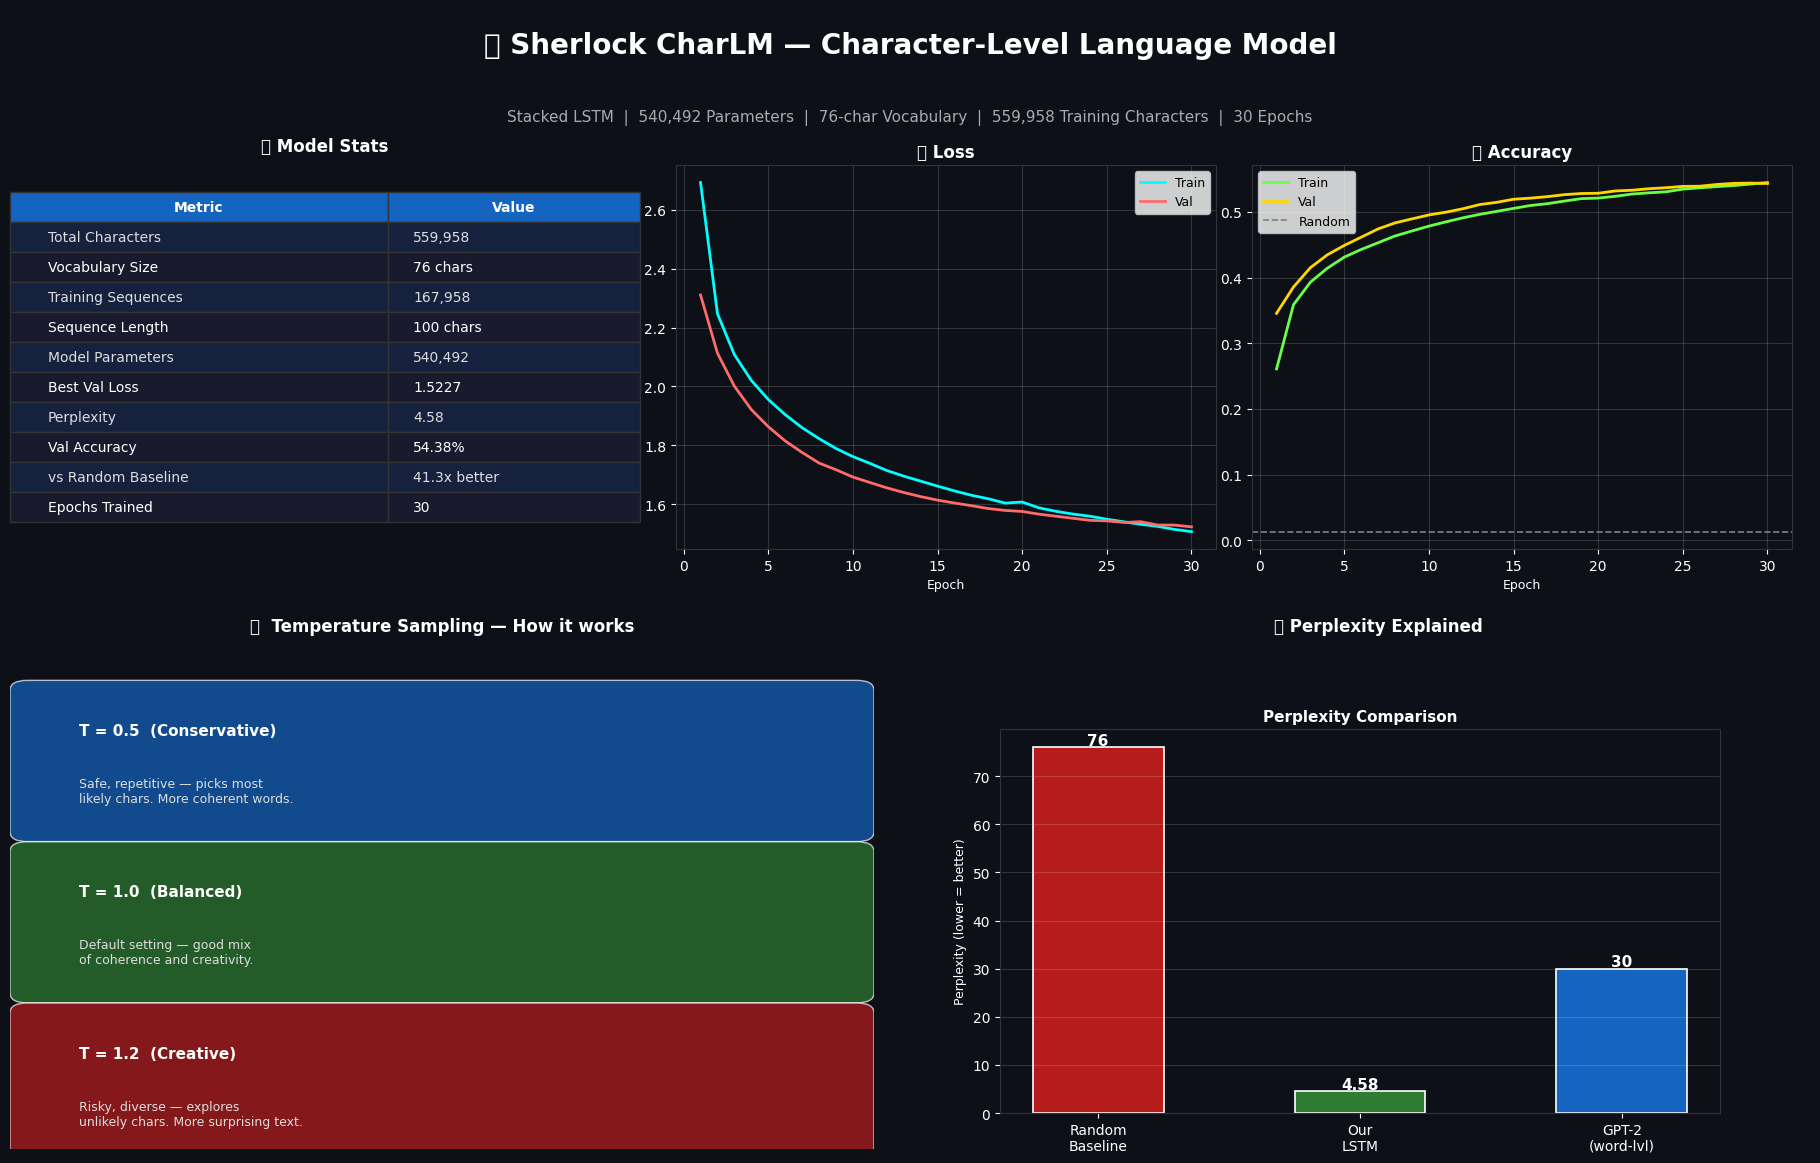

✅ Summary dashboard saved!


In [11]:
# ============================================================
# CELL 10 — Final Summary Dashboard
# ============================================================

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')

# ── Layout ─────────────────────────────────────────────────────
ax_title  = fig.add_axes([0.0,  0.88, 1.0,  0.12])
ax_stats  = fig.add_axes([0.0,  0.55, 0.35, 0.32])
ax_loss   = fig.add_axes([0.37, 0.55, 0.30, 0.32])
ax_acc    = fig.add_axes([0.69, 0.55, 0.30, 0.32])
ax_temp   = fig.add_axes([0.0,  0.05, 0.48, 0.42])
ax_perp   = fig.add_axes([0.52, 0.05, 0.48, 0.42])

for ax in [ax_title, ax_stats, ax_loss, ax_acc, ax_temp, ax_perp]:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#333')

# ── Title Panel ────────────────────────────────────────────────
ax_title.axis('off')
ax_title.text(0.5, 0.75, '🔤 Sherlock CharLM — Character-Level Language Model',
              ha='center', va='center', fontsize=20,
              fontweight='bold', color='white', transform=ax_title.transAxes)
ax_title.text(0.5, 0.25,
              'Stacked LSTM  |  540,492 Parameters  |  76-char Vocabulary  |  559,958 Training Characters  |  30 Epochs',
              ha='center', va='center', fontsize=11,
              color='#aaaaaa', transform=ax_title.transAxes)

# ── Stats Table ────────────────────────────────────────────────
ax_stats.axis('off')
stats_data = [
    ['Metric',              'Value'],
    ['Total Characters',    '559,958'],
    ['Vocabulary Size',     '76 chars'],
    ['Training Sequences',  '167,958'],
    ['Sequence Length',     '100 chars'],
    ['Model Parameters',    '540,492'],
    ['Best Val Loss',       '1.5227'],
    ['Perplexity',          '4.58'],
    ['Val Accuracy',        '54.38%'],
    ['vs Random Baseline',  '41.3x better'],
    ['Epochs Trained',      '30'],
]
table = ax_stats.table(cellText=stats_data[1:], colLabels=stats_data[0],
                        cellLoc='left', loc='center', colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#1a1a2e')
        cell.set_text_props(color='white')
    else:
        cell.set_facecolor('#16213e')
        cell.set_text_props(color='#dddddd')
    cell.set_edgecolor('#333')
ax_stats.set_title('📋 Model Stats', color='white',
                   fontsize=12, fontweight='bold', pad=10)

# ── Loss Curve ─────────────────────────────────────────────────
epochs_range = range(1, len(history.history['loss']) + 1)
ax_loss.plot(epochs_range, history.history['loss'],
             'cyan', linewidth=2, label='Train')
ax_loss.plot(epochs_range, history.history['val_loss'],
             '#FF6B6B', linewidth=2, label='Val')
ax_loss.set_title('📉 Loss', color='white', fontsize=12, fontweight='bold')
ax_loss.set_xlabel('Epoch', color='white', fontsize=9)
ax_loss.legend(fontsize=9)
ax_loss.grid(True, alpha=0.15, color='white')

# ── Accuracy Curve ─────────────────────────────────────────────
ax_acc.plot(epochs_range, history.history['accuracy'],
            '#69FF47', linewidth=2, label='Train')
ax_acc.plot(epochs_range, history.history['val_accuracy'],
            '#FFD700', linewidth=2, label='Val')
ax_acc.axhline(y=1/vocab_size, color='gray',
               linestyle='--', linewidth=1.2, label='Random')
ax_acc.set_title('📈 Accuracy', color='white', fontsize=12, fontweight='bold')
ax_acc.set_xlabel('Epoch', color='white', fontsize=9)
ax_acc.legend(fontsize=9)
ax_acc.grid(True, alpha=0.15, color='white')

# ── Temperature Comparison Bar ─────────────────────────────────
ax_temp.axis('off')
ax_temp.set_title('🌡️  Temperature Sampling — How it works',
                  color='white', fontsize=12, fontweight='bold', pad=10)
temp_data = [
    (0.5, '#1565C0', 'Conservative',
     'Safe, repetitive — picks most\nlikely chars. More coherent words.'),
    (1.0, '#2E7D32', 'Balanced',
     'Default setting — good mix\nof coherence and creativity.'),
    (1.2, '#B71C1C', 'Creative',
     'Risky, diverse — explores\nunlikely chars. More surprising text.'),
]
for i, (temp, color, label, desc) in enumerate(temp_data):
    y = 0.75 - i * 0.32
    rect = mpatches.FancyBboxPatch((0.02, y - 0.12), 0.96, 0.28,
                                    boxstyle="round,pad=0.02",
                                    facecolor=color, alpha=0.7,
                                    edgecolor='white', linewidth=1,
                                    transform=ax_temp.transAxes)
    ax_temp.add_patch(rect)
    ax_temp.text(0.08, y + 0.08, f'T = {temp}  ({label})',
                 transform=ax_temp.transAxes,
                 fontsize=11, fontweight='bold', color='white', va='center')
    ax_temp.text(0.08, y - 0.04, desc,
                 transform=ax_temp.transAxes,
                 fontsize=9, color='#dddddd', va='center')

# ── Perplexity Gauge ───────────────────────────────────────────
ax_perp.axis('off')
ax_perp.set_title('📊 Perplexity Explained', color='white',
                  fontsize=12, fontweight='bold', pad=10)
models_pp = [('Random\nBaseline', 76, '#B71C1C'),
             ('Our\nLSTM',        4.58, '#2E7D32'),
             ('GPT-2\n(word-lvl)', 30, '#1565C0')]
bars_ax = fig.add_axes([0.55, 0.08, 0.40, 0.32])
bars_ax.set_facecolor('#0d1117')
x_pos = range(len(models_pp))
bar_vals = [m[1] for m in models_pp]
bar_colors = [m[2] for m in models_pp]
bars = bars_ax.bar(x_pos, bar_vals, color=bar_colors,
                   edgecolor='white', linewidth=1.2, width=0.5)
bars_ax.set_xticks(x_pos)
bars_ax.set_xticklabels([m[0] for m in models_pp],
                         color='white', fontsize=10)
bars_ax.set_ylabel('Perplexity (lower = better)', color='white', fontsize=9)
bars_ax.tick_params(colors='white')
bars_ax.set_title('Perplexity Comparison', color='white',
                  fontsize=11, fontweight='bold')
for spine in bars_ax.spines.values():
    spine.set_color('#333')
bars_ax.grid(True, alpha=0.15, color='white', axis='y')
for bar, val in zip(bars, bar_vals):
    bars_ax.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val}', ha='center', color='white',
                 fontsize=11, fontweight='bold')

plt.savefig('sherlock_summary_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Summary dashboard saved!")

In [12]:
import io, sys
buffer = io.StringIO()
sys.stdout = buffer
model.summary()
sys.stdout = sys.__stdout__
with open('model_summary.txt', 'w') as f:
    f.write(buffer.getvalue())

print("✅ Files saved:")
print("   - best_sherlock_lstm.keras   (trained model)")
print("   - eda_sherlock.png           (EDA plots)")
print("   - sliding_window.png         (preprocessing diagram)")
print("   - lstm_architecture.png      (architecture diagram)")
print("   - training_curves.png        (loss & accuracy curves)")
print("   - sherlock_summary_dashboard.png (final dashboard)")
print("   - model_summary.txt          (model architecture)")

Model: "Sherlock_CharLM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding (Embedding)           │ (1, 100, 64)           │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_1 (LSTM)                   │ (1, 100, 256)          │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (1, 100, 256)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (1, 128)               │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (1, 76)                │         9,804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,478 (6.19 MB)

 Trainable params: 540,492 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,080,986 (4.12 MB)

✅ Files saved:
   - best_sherlock_lstm.keras   (trained model)
   - eda_sherlock.png           (EDA plots)
   - sliding_window.png         (preprocessing diagram)
   - lstm_architecture.png      (architecture diagram)
   - training_curves.png        (loss & accuracy curves)
   - sherlock_summary_dashboard.png (final dashboard)
   - model_summary.txt          (model architecture)
